# Step 1 : import libraries

In [ ]:
# Core Python / utils
import os, glob, json
from pathlib import Path
from typing import List, Dict, Tuple
import numpy as np

# Image I/O and processing
import cv2
import matplotlib.pyplot as plt

# HOG from scikit-image
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage.transform import resize

# ML tools
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support,
)

# Progress bars
from tqdm import tqdm

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical, plot_model
from IPython.display import Image

import os, numpy as np, matplotlib.pyplot as plt, pandas as pd
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             accuracy_score, precision_recall_fscore_support)
import os, matplotlib.pyplot as plt, numpy as np

# Step 2 : Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/archive"
data_train_path = "/content/drive/MyDrive/archive/train"
data_test_path = "/content/drive/MyDrive/archive/test"
data_val_path = "/content/drive/MyDrive/archive/val"

In [ ]:
imgw, imgh = 180, 180

data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path, image_size=(imgw, imgh), batch_size=32,
    shuffle=False, label_mode="int"
)
class_names = data_train.class_names

data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path, image_size=(imgw, imgh), batch_size=32,
    shuffle=False, label_mode="int", class_names=class_names
)
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path, image_size=(imgw, imgh), batch_size=32,
    shuffle=False, label_mode="int", class_names=class_names
)
print("Classes:", class_names)

Found 929 files belonging to 6 classes.
Found 550 files belonging to 6 classes.
Found 95 files belonging to 6 classes.
Classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


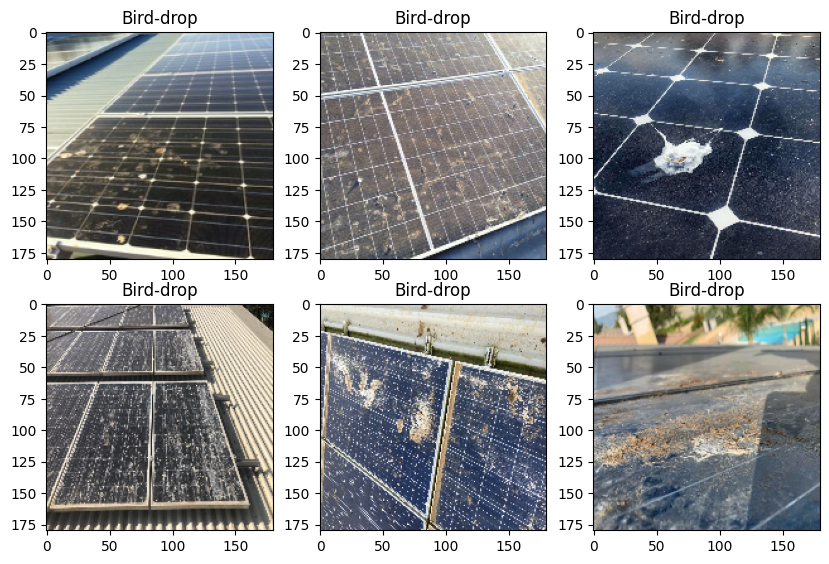

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in data_train.take(1):
  for i in range(6):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])

# Part 1: for HOG

## STEP 3: Implementing HOG

In [ ]:
def hog_one(img, size=(128, 128)):
    """
    I take ONE RGB image tensor/array from the dataset and turn it into a 1D HOG feature vector.
    - img shape is (H, W, 3), values in [0, 255] coming from tf.data
    - I return a float32 vector so sklearn/keras can use it directly.
    """
    img = img / 255.0                         # I normalize pixels to [0,1] because HOG works better on scaled images
    g   = rgb2gray(img)                        # HOG is usually computed on grayscale, so I convert RGB -> gray
    g   = resize(g, size, anti_aliasing=True)  # I resize so every image gives the SAME feature length
    f   = hog(                                 # I compute HOG with classic settings (works well for many datasets)
        g,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True                    # I want a single flat vector, not the multi-d grid
    )
    return f.astype(np.float32)                # I force float32 to save memory and avoid dtype issues


def ds_to_hog(ds, size=(128, 128)):
    """
    I convert a tf.data.Dataset (batches of (images, labels)) into:
      X: HOG feature matrix of shape [N, D]
      y: integer labels of shape [N]
    Steps:
    - I loop over batches as NumPy arrays
    - For each image, I call hog_one(...)
    - I collect features and labels, then stack them at the end
    """
    feats, labels = [], []
    for xb, yb in ds.as_numpy_iterator():      # I grab each batch as NumPy (xb: (B,H,W,3), yb: (B,))
        for img, y in zip(xb, yb):             # I iterate inside the batch, one image at a time
            feats.append(hog_one(img, size))   # I extract HOG for this image
            labels.append(int(y))              # I store its integer class id
    X = np.vstack(feats)                       # I stack list of vectors -> 2D array [N, D]
    y = np.array(labels, dtype=np.int32)       # I turn the label list into a 1D int array
    return X, y


# I build the HOG feature matrices for each split using the SAME size
Xtr_hog, ytr = ds_to_hog(data_train, (128, 128))
Xva_hog, yva = ds_to_hog(data_val,   (128, 128))
Xte_hog, yte = ds_to_hog(data_test,  (128, 128))
print("HOG shapes:", Xtr_hog.shape, Xva_hog.shape, Xte_hog.shape)  # I confirm dimensions are as expected

HOG shapes: (929, 8100) (550, 8100) (95, 8100)


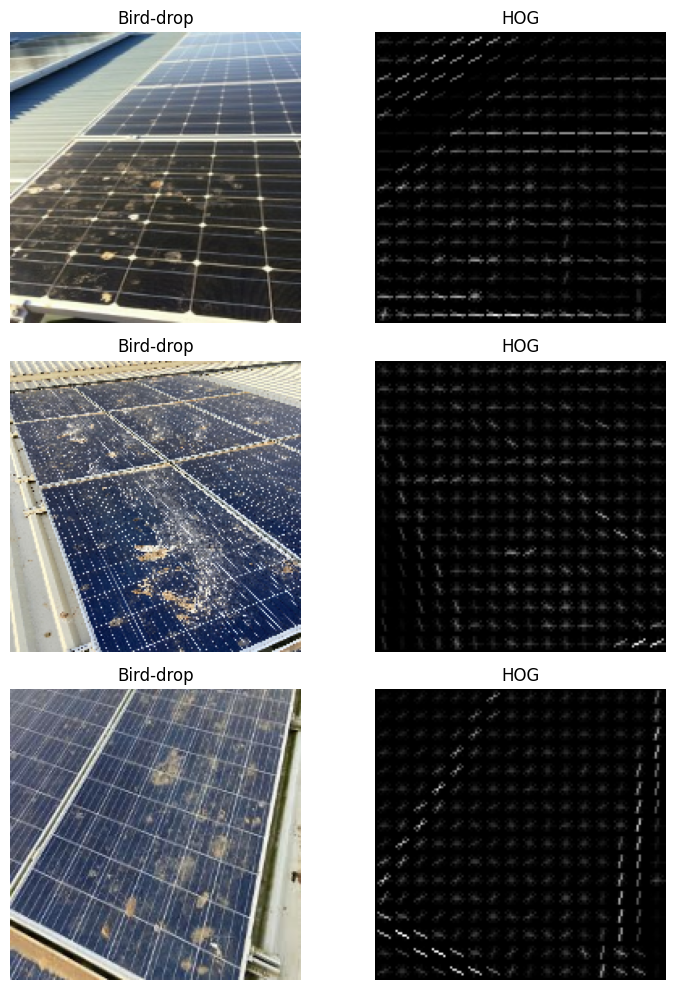

In [ ]:
def show_hog_3(ds, class_names, size=(128, 128)):
    """
    I visualize HOG for 3 images to make sure preprocessing looks right.
    - I take one batch from the dataset
    - I pick first, middle, last images
    - I show the original (normalized) and the HOG visualization side by side
    """
    xb, yb = next(ds.as_numpy_iterator())          # I take one batch only (fast preview)
    idxs = [0, len(xb)//2, len(xb)-1]              # I choose 3 sample indices (first/middle/last)

    plt.figure(figsize=(8, 10))
    for i, idx in enumerate(idxs):
        rgb = xb[idx] / 255.0                      # I normalize to [0,1] just for nicer display
        g   = rgb2gray(resize(rgb, size, anti_aliasing=True))  # I match the exact HOG resize
        _, vis = hog(                              # I recompute HOG with visualize=True for the picture
            g,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            visualize=True,
            feature_vector=True
        )
        # I draw original image and its HOG side-by-side
        plt.subplot(3, 2, 2*i+1); plt.imshow(rgb);    plt.title(class_names[int(yb[idx])]); plt.axis('off')
        plt.subplot(3, 2, 2*i+2); plt.imshow(vis, cmap='gray'); plt.title('HOG'); plt.axis('off')

    plt.tight_layout(); plt.show()


# I preview three examples from the training set
show_hog_3(data_train, class_names)


## STEP 4: Standardize before training

In [ ]:
# I fit the scaler ONLY on the TRAIN features to learn per-dimension mean and std (avoid data leakage)
scaler = StandardScaler().fit(Xtr_hog)

# I standardize each split using the TRAIN stats so all features are ~zero-mean, unit-variance
Xtr_hog_s = scaler.transform(Xtr_hog)  # scaled train (this is what I use to fit models)
Xva_hog_s = scaler.transform(Xva_hog)  # scaled val   (for tuning/early stopping)
Xte_hog_s = scaler.transform(Xte_hog)  # scaled test  (for final, unbiased evaluation)


# Part 1: for SIFT

In [ ]:
!pip install opencv-contrib-python

## STEP 3: Implementing SIFT

In [ ]:

def ds_to_sift_desc(ds, size=(128,128)):
    """
    I convert a tf.data.Dataset of (RGB batch, label batch) into:
      - descs: a Python list where each item is an array of SIFT descriptors for ONE image (shape [n_kp, 128])
      - y:     a 1D numpy array of integer labels (one label per image)
    I also resize to a fixed size so descriptor density is comparable across images.
    """
    sift = cv2.SIFT_create()              # I create a SIFT detector/extractor (128-D descriptors)
    descs, labels = [], []

    for imgs, ys in ds:                   # I iterate over dataset batches
        imgs_np = imgs.numpy()            # (B,H,W,3) float32 in [0,255]
        ys_np   = ys.numpy()              # (B,) int labels

        for i in range(imgs_np.shape[0]): # I loop over images inside the batch
            rgb = imgs_np[i].astype(np.uint8)                 # I cast to uint8 for OpenCV
            g   = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)       # I convert to grayscale for SIFT
            g   = cv2.resize(g, size, interpolation=cv2.INTER_AREA)  # I resize for consistency

            # I detect keypoints and compute SIFT descriptors (shape [n_kp, 128] or None)
            _, des = sift.detectAndCompute(g, None)

            if des is None:                                   # If no keypoints/descriptors were found
                des = np.zeros((0, 128), dtype=np.float32)    # I store an empty (0x128) array
            else:
                des = des.astype(np.float32)                  # I ensure float32 for downstream steps

            descs.append(des)                                 # I keep descriptors for this image
        labels.append(ys_np)                                  # I keep labels for this batch

    y = np.concatenate(labels).astype(np.int32)               # I stack batch labels into one array [N]
    return descs, y


# 1) I extract per-image SIFT descriptors for each split (fit codebook on TRAIN only to avoid leakage)
tr_desc, ytr = ds_to_sift_desc(data_train, size=(128,128))
va_desc, yva = ds_to_sift_desc(data_val,   size=(128,128))
te_desc, yte = ds_to_sift_desc(data_test,  size=(128,128))


def build_codebook(desc_list, k=200, max_desc=100_000):
    """
    I build a visual vocabulary (codebook) using MiniBatchKMeans.
    - k is the number of visual words (histogram bins).
    - I stack descriptors from all TRAIN images, optionally subsample to max_desc for speed.
    - I return a fitted KMeans model (each cluster center = one visual word).
    """
    valid = [d for d in desc_list if len(d) > 0]              # I keep only images that have descriptors
    if not valid:
        raise ValueError("No SIFT descriptors found in training images.")

    all_desc = np.vstack(valid)                               # [total_desc, 128]
    if all_desc.shape[0] > max_desc:                         # I cap descriptors to keep KMeans fast
        idx = np.random.choice(all_desc.shape[0], max_desc, replace=False)
        all_desc = all_desc[idx]

    # I fit MiniBatchKMeans to learn k cluster centers (the "visual words")
    return MiniBatchKMeans(n_clusters=k, batch_size=4096, n_init='auto').fit(all_desc)


kmeans = build_codebook(tr_desc, k=200)  # I choose k=200 as a reasonable BoVW size (you can tune later)


def to_bovw(des, kmeans):
    """
    I convert the SIFT descriptors of ONE image into a fixed-length BoVW histogram:
    - I assign each 128-D descriptor to its nearest visual word (cluster index).
    - I count how many times each word appears → histogram length = k.
    - I L2-normalize the histogram so images with more keypoints don't dominate.
    """
    k = kmeans.n_clusters
    if len(des) == 0:
        hist = np.zeros(k, dtype=np.float32)                  # no descriptors → all zeros
    else:
        words = kmeans.predict(des)                           # [n_kp] each in [0..k-1]
        hist, _ = np.histogram(words, bins=range(k+1))        # counts per word
        hist = hist.astype(np.float32)

    hist /= (np.linalg.norm(hist) + 1e-8)                     # L2 normalize for fair comparison
    return hist


# 2) I convert variable-length descriptor sets into fixed-length histograms for each split
Xtr_bovw = np.stack([to_bovw(d, kmeans) for d in tr_desc])    # [N_train, k]
Xva_bovw = np.stack([to_bovw(d, kmeans) for d in va_desc])    # [N_val,   k]
Xte_bovw = np.stack([to_bovw(d, kmeans) for d in te_desc])    # [N_test,  k]



## STEP 4: Standardize before training

In [ ]:
# 3) Standardize (fit on TRAIN only)
bow_scaler = StandardScaler().fit(Xtr_bovw)
Xtr_bow_s  = bow_scaler.transform(Xtr_bovw)
Xva_bow_s  = bow_scaler.transform(Xva_bovw)
Xte_bow_s  = bow_scaler.transform(Xte_bovw)


In [ ]:
import os
os.makedirs("results", exist_ok=True)


# Part 1: ALL classical models (HOG SIFT)

[HOG+SVM] Test Accuracy = 0.8526


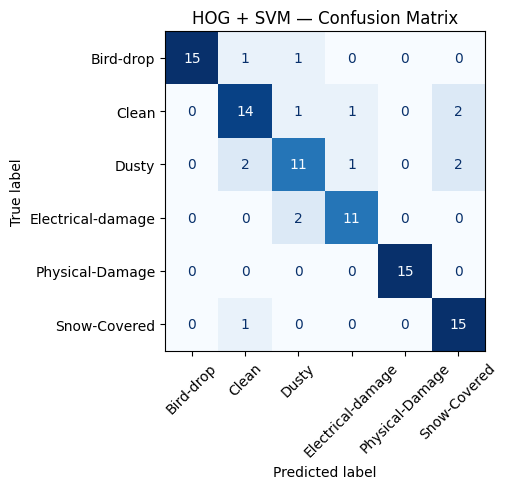

[HOG+KNN] Test Accuracy = 0.8316


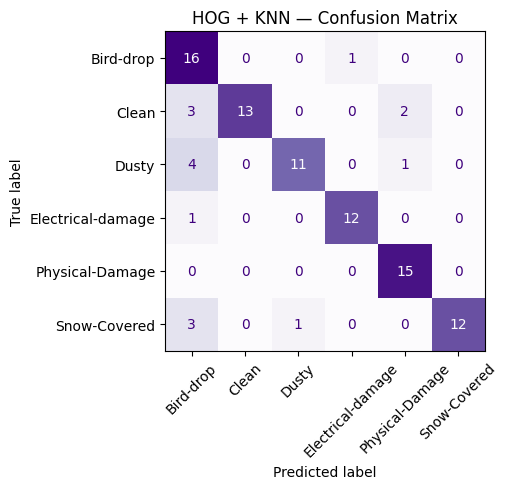

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[HOG+ANN] Test Accuracy = 0.9158 | Test Loss = 0.3986


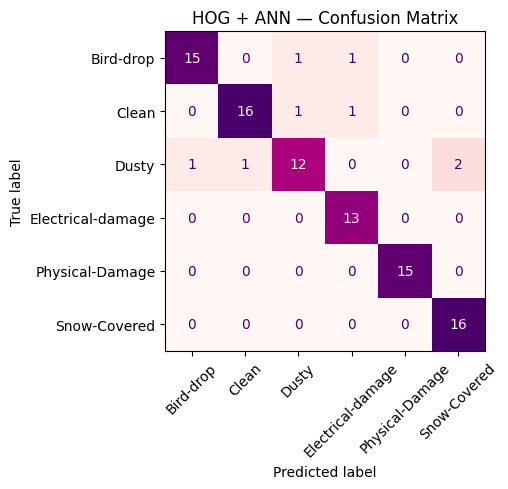

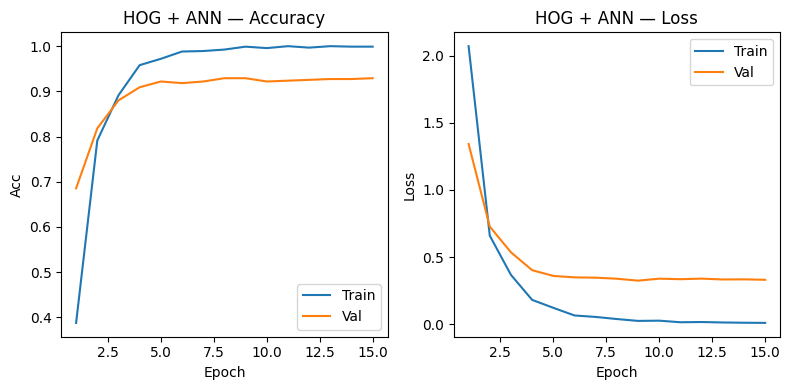

[BoVW+SVM] Test Accuracy = 0.8632


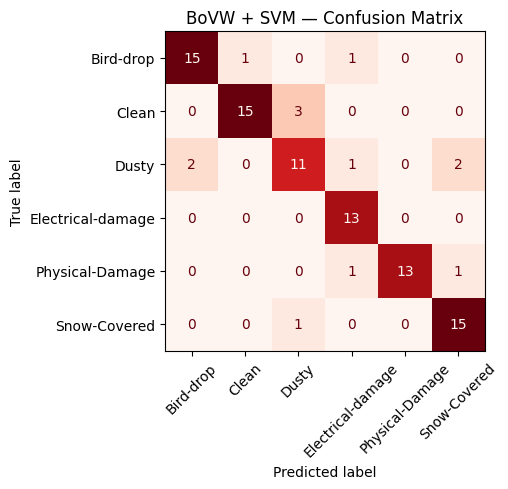

[BoVW+KNN] Test Accuracy = 0.8737


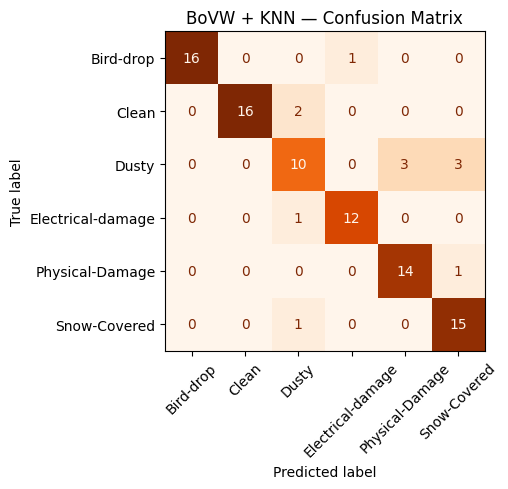

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[BoVW+ANN] Test Accuracy = 0.9368 | Test Loss = 0.2786


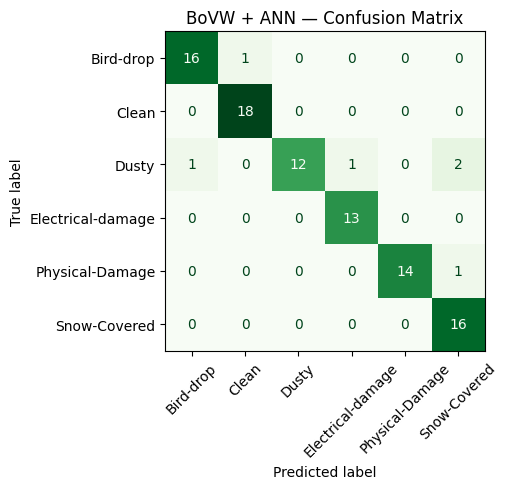

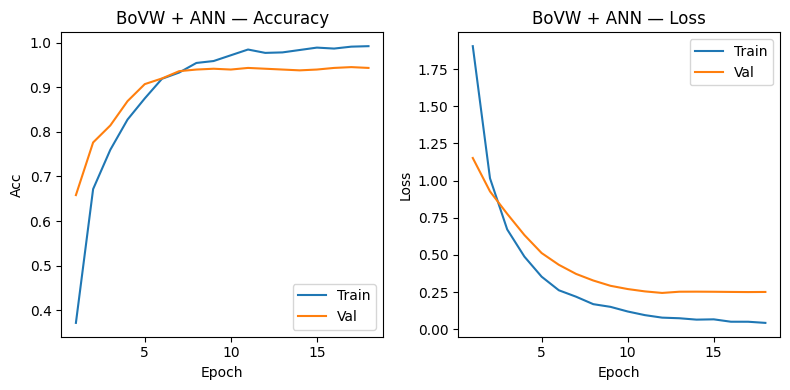

In [ ]:
# ===================== IMPROVED CLASSICAL MODELS (with rationale) =====================
# Assumptions:
# - Xtr_hog_s, Xva_hog_s, Xte_hog_s are HOG features already standardized with StandardScaler.
#   I standardized because SVM, KNN, and MLP are sensitive to feature scale, so scaling usually boosts accuracy.
# - Xtr_bow_s, Xva_bow_s, Xte_bow_s are BoVW histograms (SIFT→k-means→hist), also standardized for the same reason.
# - ytr, yva, yte are integer class IDs. class_names is a list of readable class labels for the confusion matrices.

# --------------------- HOG: SVM ---------------------
# Why SVM with RBF on HOG:
# - HOG creates high-dimensional, non-linear separations between classes, so a non-linear kernel fits better than linear.
# - kernel='rbf': lets SVM draw curved decision boundaries that match HOG structure.
# - C=1.0: regularization strength. I kept it modest to avoid overfitting after scaling.
# - gamma='scale': sets gamma = 1 / (n_features * Var), a robust default that adapts to my data size and variance.
# - random_state=42: reproducibility so I get the same split behavior when SVC does internal shuffles.
import os, joblib
os.makedirs("models", exist_ok=True)


svm_hog = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
svm_hog.fit(Xtr_hog_s, ytr)  # train on scaled HOG
joblib.dump(svm_hog, "models/HOG_SVM.pkl")

# Evaluate on test HOG features
yp = svm_hog.predict(Xte_hog_s)
acc = accuracy_score(yte, yp)
print(f"[HOG+SVM] Test Accuracy = {acc:.4f}")

# Confusion matrix is essential to see per-class strengths and weaknesses, not just overall accuracy
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(yte, yp), display_labels=class_names)\
    .plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("HOG + SVM — Confusion Matrix")
plt.tight_layout(); plt.savefig("results/CM_HOG_SVM_Blues.png", dpi=150); plt.show()


# --------------------- HOG: KNN ---------------------
# Why KNN on HOG:
# - KNN is a strong, simple non-parametric baseline. It benefits a lot from scaling because it uses distances directly.
# - n_neighbors=5: common stable default, balances bias and variance for medium sized datasets.
# - weights='distance': closer neighbors matter more, helpful when classes overlap in feature space.
# - p=2: Euclidean distance, which matches the StandardScaler assumption and works well with HOG vectors.
knn_hog = KNeighborsClassifier(n_neighbors=5, weights='distance', p=2)
knn_hog.fit(Xtr_hog_s, ytr)  # no iterative training, it just stores the training set
joblib.dump(knn_hog, "models/HOG_KNN.pkl")

yp = knn_hog.predict(Xte_hog_s)
acc = accuracy_score(yte, yp)
print(f"[HOG+KNN] Test Accuracy = {acc:.4f}")

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(yte, yp), display_labels=class_names)\
    .plot(ax=ax, cmap="Purples", colorbar=False, xticks_rotation=45)
ax.set_title("HOG + KNN — Confusion Matrix")
plt.tight_layout(); plt.savefig("results/CM_HOG_KNN_Purples.png", dpi=150); plt.show()
# Note: KNN has no training curve, there is no gradient descent. The model is “lazy”, it predicts via stored data.


# --------------------- HOG: ANN / MLP ---------------------
# Why this small MLP for HOG:
# - HOG is tabular-like and high dimensional. A compact MLP can learn non-linear combinations without overfitting too much.
# - Dense(512) then Dense(256): enough capacity to learn patterns, but not too large to overfit.
# - BatchNormalization: stabilizes activations, speeds up and smooths training, works well with ReLU.
# - Dropout(0.3): randomly drops units during training, reduces overfitting and improves generalization.
# - Softmax + sparse_categorical_crossentropy: labels are integer IDs, so I avoid creating one-hot vectors.
# - EarlyStopping + ReduceLROnPlateau: stop when val_loss stops improving and lower LR automatically if stuck.
ann_hog = Sequential([
    Dense(512, activation='relu', input_shape=(Xtr_hog_s.shape[1],)),  # first hidden layer, main capacity
    BatchNormalization(), Dropout(0.3),  # stabilizes and regularizes
    Dense(256, activation='relu'),       # second hidden layer, more depth to capture complex patterns
    BatchNormalization(), Dropout(0.3),  # more regularization
    Dense(len(class_names), activation='softmax')  # output for multi-class
])

ann_hog.compile(
    optimizer='adam',                       # Adam works well out of the box for MLPs
    loss='sparse_categorical_crossentropy', # integer labels, no one-hot needed
    metrics=['accuracy']
)

# I increased epochs from 30 to 60 to give the model time to converge,
# but EarlyStopping(patience=6) prevents me from overfitting or wasting time if validation stops improving.
ann_hog_hist = ann_hog.fit(
    Xtr_hog_s, ytr,
    validation_data=(Xva_hog_s, yva),
    epochs=60, batch_size=64, verbose=0,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
    ]
)

ann_hog.save("models/HOG_ANN.keras")

# Final test evaluation, I report both accuracy and loss
test_loss, test_acc = ann_hog.evaluate(Xte_hog_s, yte, verbose=0)
print(f"[HOG+ANN] Test Accuracy = {test_acc:.4f} | Test Loss = {test_loss:.4f}")

# Confusion matrix to inspect class-wise behavior after training
yp = ann_hog.predict(Xte_hog_s, verbose=0).argmax(axis=1)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(yte, yp), display_labels=class_names)\
    .plot(ax=ax, cmap="RdPu", colorbar=False, xticks_rotation=45)
ax.set_title("HOG + ANN — Confusion Matrix")
plt.tight_layout(); plt.savefig("results/CM_HOG_ANN_Pink.png", dpi=150); plt.show()

# Learning curves help me check overfitting or underfitting visually
h = ann_hog_hist.history
acc_tr  = h.get("accuracy", h.get("acc"))
acc_val = h.get("val_accuracy", h.get("val_acc"))
loss_tr = h["loss"]; loss_val = h["val_loss"]
e = range(1, len(loss_tr)+1)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(e, acc_tr,  label="Train"); plt.plot(e, acc_val, label="Val")
plt.title("HOG + ANN — Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend()
plt.subplot(1,2,2)
plt.plot(e, loss_tr, label="Train"); plt.plot(e, loss_val, label="Val")
plt.title("HOG + ANN — Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.savefig("results/curve_HOG_ANN.png", dpi=150); plt.show()


# ===================== SIFT → BoVW (Bag of Visual Words) =====================
# Reminder:
# - SIFT finds local keypoints, k-means clusters them into a codebook, then each image is a histogram over k visual words.
# - Standardizing BoVW histograms helps distance-based methods and MLP training.

# --------------------- BoVW: SVM ---------------------
# Same SVM reasoning as HOG:
# - BoVW histograms are not linearly separable in many cases, so I use RBF.
# - gamma='scale' adapts to number of bins and data variance automatically.
svm_bow = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
svm_bow.fit(Xtr_bow_s, ytr)

joblib.dump(svm_bow, "models/BoVW_SVM.pkl")

yp = svm_bow.predict(Xte_bow_s)
acc = accuracy_score(yte, yp)
print(f"[BoVW+SVM] Test Accuracy = {acc:.4f}")

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(yte, yp), display_labels=class_names)\
    .plot(ax=ax, cmap="Reds", colorbar=False, xticks_rotation=45)
ax.set_title("BoVW + SVM — Confusion Matrix")
plt.tight_layout(); plt.savefig("results/CM_BoVW_SVM_Reds.png", dpi=150); plt.show()


# --------------------- BoVW: KNN ---------------------
# KNN fits BoVW well because histograms are naturally compared by distances.
# - k=5 keeps it stable, weights='distance' gives more vote to closer histograms.
knn_bow = KNeighborsClassifier(n_neighbors=5, weights='distance', p=2)
knn_bow.fit(Xtr_bow_s, ytr)

# --------------------- BoVW: KNN ---------------------
joblib.dump(knn_bow, "models/BoVW_KNN.pkl")




yp = knn_bow.predict(Xte_bow_s)
acc = accuracy_score(yte, yp)
print(f"[BoVW+KNN] Test Accuracy = {acc:.4f}")

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(yte, yp), display_labels=class_names)\
    .plot(ax=ax, cmap="Oranges", colorbar=False, xticks_rotation=45)
ax.set_title("BoVW + KNN — Confusion Matrix")
plt.tight_layout(); plt.savefig("results/CM_BoVW_KNN_Oranges.png", dpi=150); plt.show()
# Again, KNN has no training curve because there is no iterative optimization.


# --------------------- BoVW: ANN / MLP ---------------------
# The same compact MLP design works for BoVW histograms:
# - Two dense layers to capture non-linear combinations of codeword bins.
# - BatchNorm + Dropout for regularization and stable training.
num_classes = len(class_names)
ann_bow = Sequential([
    Dense(512, activation='relu', input_shape=(Xtr_bow_s.shape[1],)),  # capacity to model k-bin histograms
    BatchNormalization(), Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

ann_bow.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Same training strategy as HOG MLP. More epochs, but guarded by EarlyStopping.
ann_bow_hist = ann_bow.fit(
    Xtr_bow_s, ytr,
    validation_data=(Xva_bow_s, yva),
    epochs=60, batch_size=64, verbose=0,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
    ]
)
# --------------------- BoVW: ANN ---------------------
ann_bow.save("models/BoVW_ANN.keras")

test_loss, test_acc = ann_bow.evaluate(Xte_bow_s, yte, verbose=0)
print(f"[BoVW+ANN] Test Accuracy = {test_acc:.4f} | Test Loss = {test_loss:.4f}")

yp = ann_bow.predict(Xte_bow_s, verbose=0).argmax(axis=1)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(yte, yp), display_labels=class_names)\
    .plot(ax=ax, cmap="Greens", colorbar=False, xticks_rotation=45)
ax.set_title("BoVW + ANN — Confusion Matrix")
plt.tight_layout(); plt.savefig("results/CM_BoVW_ANN_Greens.png", dpi=150); plt.show()

# BoVW learning curves, to verify generalization
h = ann_bow_hist.history
acc_tr  = h.get("accuracy", h.get("acc"))
acc_val = h.get("val_accuracy", h.get("val_acc"))
loss_tr = h["loss"]; loss_val = h["val_loss"]
e = range(1, len(loss_tr)+1)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(e, acc_tr,  label="Train"); plt.plot(e, acc_val, label="Val")
plt.title("BoVW + ANN — Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend()
plt.subplot(1,2,2)
plt.plot(e, loss_tr, label="Train"); plt.plot(e, loss_val, label="Val")
plt.title("BoVW + ANN — Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.savefig("results/curve_BoVW_ANN.png", dpi=150); plt.show()


# Part 2: Improvement for CNN

i stopped training once i noticed the accuracy dosent perform right and decided to shuffle the datase for cnn (next cell)

### Training and evalute CNN after improvement
After I shuffeled the dataset and used it for model with dropout and without

In [ ]:
# Train/evaluate two CNN variants (KEEP SHUFFLING) and print both Keras evaluate() and sklearn metrics.num_classes = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE

# Datasets
train_cnn = data_train.shuffle(1000, seed=42, reshuffle_each_iteration=True).cache().prefetch(AUTOTUNE)
val_cnn   = data_val.cache().prefetch(AUTOTUNE)
test_cnn  = data_test.cache().prefetch(AUTOTUNE)

# ---------- A) CNN without Dropout ----------
model_no = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model_no.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_no = model_no.fit(train_cnn, validation_data=val_cnn, epochs=25, verbose=1)
model_no.save("models/CNN_NoDropout.keras")


# Keras evaluate (loss, acc)
test_loss_no, test_acc_no = model_no.evaluate(test_cnn, verbose=0)
print(f"[Keras evaluate] CNN No Dropout — loss={test_loss_no:.4f}, acc={test_acc_no:.4f}")

# Sklearn metrics (need predictions anyway for later CMs)
y_true_cnn = np.concatenate([y.numpy() for _, y in test_cnn], axis=0)  # build once, reused below
y_prob_cnn_no = model_no.predict(test_cnn, verbose=0)
y_pred_cnn_no = y_prob_cnn_no.argmax(axis=1)
acc_no = accuracy_score(y_true_cnn, y_pred_cnn_no)
p_no, r_no, f1_no, _ = precision_recall_fscore_support(y_true_cnn, y_pred_cnn_no, average='macro', zero_division=0)
print(f"[Sklearn] CNN No Dropout — Acc={acc_no:.3f}  Macro-P={p_no:.3f}  Macro-R={r_no:.3f}  Macro-F1={f1_no:.3f}")

# ---------- B) CNN with Dropout=0.20 ----------
model_do = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.20),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model_do.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_do = model_do.fit(train_cnn, validation_data=val_cnn, epochs=25, verbose=1)
model_do.save("models/CNN_Dropout020.keras")

# Keras evaluate (loss, acc)
test_loss_do, test_acc_do = model_do.evaluate(test_cnn, verbose=0)
print(f"[Keras evaluate] CNN Dropout 0.20 — loss={test_loss_do:.4f}, acc={test_acc_do:.4f}")

# Sklearn metrics
y_prob_cnn_do = model_do.predict(test_cnn, verbose=0)
y_pred_cnn_do = y_prob_cnn_do.argmax(axis=1)
acc_do = accuracy_score(y_true_cnn, y_pred_cnn_do)
p_do, r_do, f1_do, _ = precision_recall_fscore_support(y_true_cnn, y_pred_cnn_do, average='macro', zero_division=0)
print(f"[Sklearn] CNN Dropout 0.20 — Acc={acc_do:.3f}  Macro-P={p_do:.3f}  Macro-R={r_do:.3f}  Macro-F1={f1_do:.3f}")

# Summary
print(f"Summary — Keras Acc: No-DO={test_acc_no:.3f} | DO(0.20)={test_acc_do:.3f}")
print(f"Summary — Sklearn Macro-F1: No-DO={f1_no:.3f} | DO(0.20)={f1_do:.3f}")



Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 192ms/step - accuracy: 0.0196 - loss: 2.6443 - val_accuracy: 0.1945 - val_loss: 1.7906
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0543 - loss: 1.7937 - val_accuracy: 0.1855 - val_loss: 1.7841
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1072 - loss: 1.7949 - val_accuracy: 0.2727 - val_loss: 1.7897
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1615 - loss: 1.7977 - val_accuracy: 0.1982 - val_loss: 1.7761
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1083 - loss: 1.8100 - val_accuracy: 0.1855 - val_loss: 1.8065
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1062 - loss: 1.8606 - val_accuracy: 0.2564 - val_loss: 1.7879
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1815 - loss: 1.8328 - val_accuracy: 0.1927 - val_loss: 1.7895
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0653 - loss: 1.7932 - val_accuracy: 0.1945 -

### Training curves CNN

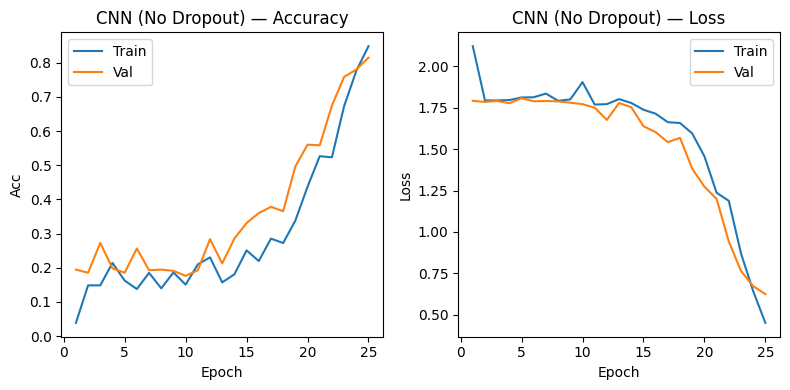

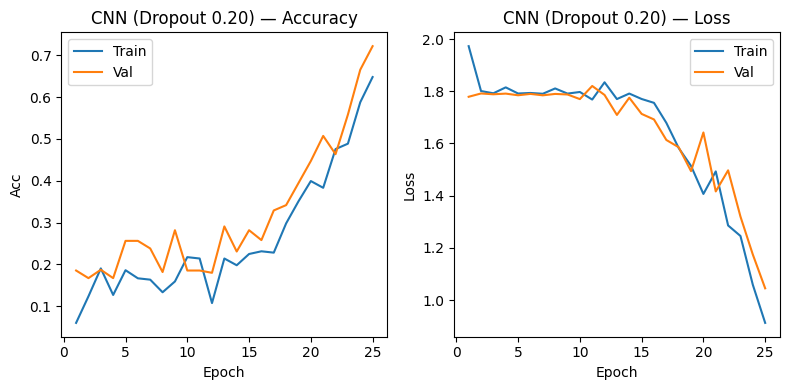

In [ ]:
import matplotlib.pyplot as plt

# ----- Curves: CNN (No Dropout) -----
H = hist_no.history
e = range(1, len(H["loss"]) + 1)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(e, H.get("accuracy", H.get("acc")), label="Train")
plt.plot(e, H.get("val_accuracy", H.get("val_acc")), label="Val")
plt.title("CNN (No Dropout) — Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend()

plt.subplot(1,2,2)
plt.plot(e, H["loss"], label="Train")
plt.plot(e, H["val_loss"], label="Val")
plt.title("CNN (No Dropout) — Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout(); plt.savefig("results/curve_CNN_NoDropout.png", dpi=150); plt.show()

# ----- Curves: CNN (Dropout 0.20) -----
H = hist_do.history
e = range(1, len(H["loss"]) + 1)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(e, H.get("accuracy", H.get("acc")), label="Train")
plt.plot(e, H.get("val_accuracy", H.get("val_acc")), label="Val")
plt.title("CNN (Dropout 0.20) — Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend()

plt.subplot(1,2,2)
plt.plot(e, H["loss"], label="Train")
plt.plot(e, H["val_loss"], label="Val")
plt.title("CNN (Dropout 0.20) — Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout(); plt.savefig("results/curve_CNN_Dropout020.png", dpi=150); plt.show()


# 3-FOLD CROSS VALIDATION FOR ANN WITH SIFT


3-FOLD Cross Validation — ANN + SIFT/BoVW

----- Fold 1 -----


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Accuracy = 0.7890

----- Fold 2 -----


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Accuracy = 0.7525

----- Fold 3 -----


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3 Accuracy = 0.7992

CV Accuracies: [0.7890466531440162, 0.7525354969574036, 0.7991886409736308]
Mean = 0.7803   Std = 0.0200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Saved final ANN SIFT model → models/ANN_SIFT_3FoldCV.keras

Final Model on Test Set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        16

    accuracy                           1.00        95
   macro avg       1.00      1.00      1.00        95
weighted avg       1.00      1.00      1.00        95



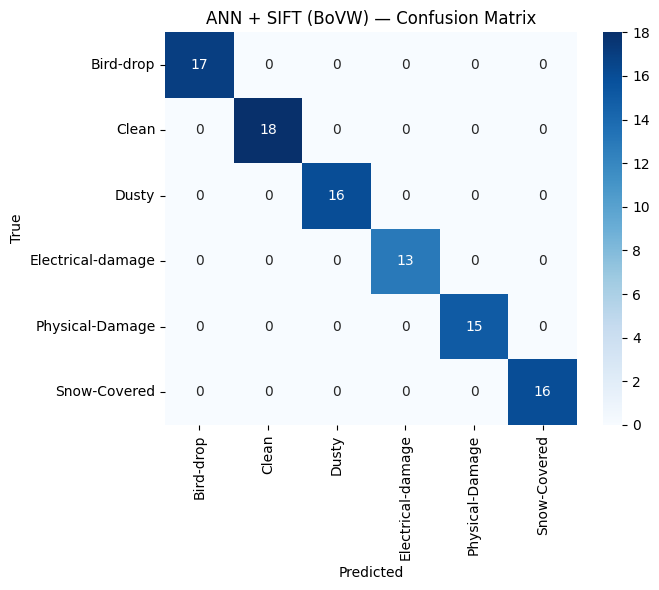

In [ ]:
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
import matplotlib.pyplot as plt
import seaborn as sns



# ------------------------------------------
# COMBINE TRAIN + VALIDATION
# ------------------------------------------
X_bow_full = np.concatenate([Xtr_bow_s, Xva_bow_s], axis=0)
y_bow_full = np.concatenate([ytr, yva], axis=0)

num_classes = len(class_names)
input_dim = X_bow_full.shape[1]

# ------------------------------------------
# 3-FOLD CROSS VALIDATION
# ------------------------------------------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = []

def build_ann_model():
    """Creates the ANN model using your exact architecture."""
    model = Sequential([
        Dense(512, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("\n============================")
print("3-FOLD Cross Validation — ANN + SIFT/BoVW")
print("============================")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_bow_full, y_bow_full), 1):
    print(f"\n----- Fold {fold} -----")

    X_tr, X_val = X_bow_full[train_idx], X_bow_full[val_idx]
    y_tr_f, y_val_f = y_bow_full[train_idx], y_bow_full[val_idx]

    model = build_ann_model()

    model.fit(
        X_tr, y_tr_f,
        epochs=30,
        batch_size=64,
        verbose=0
    )

    y_val_pred = model.predict(X_val, verbose=0).argmax(axis=1)
    acc = accuracy_score(y_val_f, y_val_pred)
    cv_scores.append(acc)

    print(f"Fold {fold} Accuracy = {acc:.4f}")

print("\nCV Accuracies:", cv_scores)
print(f"Mean = {np.mean(cv_scores):.4f}   Std = {np.std(cv_scores):.4f}")

# ------------------------------------------
# TRAIN FINAL MODEL ON FULL TRAIN+VAL
# ------------------------------------------
final_model = build_ann_model()
final_model.fit(
    X_bow_full, y_bow_full,
    epochs=30,
    batch_size=64,
    verbose=0
)

# ------------------------------------------
# SAVE MODEL
# ------------------------------------------
save_path = "models/ANN_SIFT_3FoldCV.keras"
final_model.save(save_path)
print(f"\nSaved final ANN SIFT model → {save_path}")

# ------------------------------------------
# TEST EVALUATION
# ------------------------------------------
y_test_pred = final_model.predict(Xte_bow_s, verbose=0).argmax(axis=1)

print("\n============================")
print("Final Model on Test Set")
print("============================")
print(classification_report(yte, y_test_pred))

cm = confusion_matrix(yte, y_test_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, cmap="Blues", fmt="d",
    xticklabels=class_names, yticklabels=class_names
)
plt.title("ANN + SIFT (BoVW) — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("results/CM_ANN_SIFT_BoVW.png")
plt.show()


# Part 3 : Confusion Matrices for both(classical and CNN)



HOG + SVM — Classification Report
                   precision    recall  f1-score   support

        Bird-drop      1.000     0.882     0.938        17
            Clean      0.778     0.778     0.778        18
            Dusty      0.733     0.688     0.710        16
Electrical-damage      0.846     0.846     0.846        13
  Physical-Damage      1.000     1.000     1.000        15
     Snow-Covered      0.789     0.938     0.857        16

         accuracy                          0.853        95
        macro avg      0.858     0.855     0.855        95
     weighted avg      0.856     0.853     0.853        95



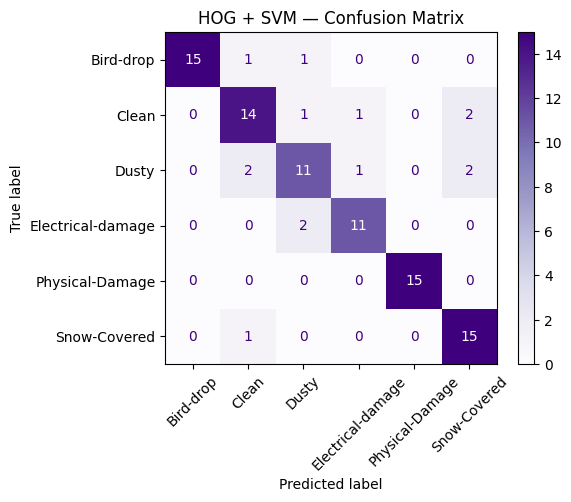


HOG + KNN — Classification Report
                   precision    recall  f1-score   support

        Bird-drop      0.593     0.941     0.727        17
            Clean      1.000     0.722     0.839        18
            Dusty      0.917     0.688     0.786        16
Electrical-damage      0.923     0.923     0.923        13
  Physical-Damage      0.833     1.000     0.909        15
     Snow-Covered      1.000     0.750     0.857        16

         accuracy                          0.832        95
        macro avg      0.878     0.837     0.840        95
     weighted avg      0.876     0.832     0.836        95



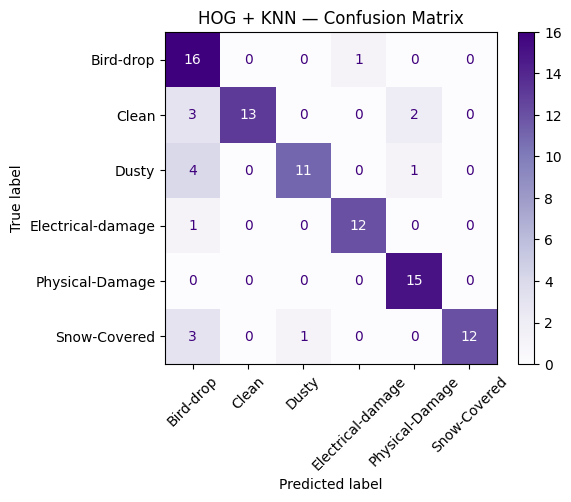


HOG + ANN — Classification Report
                   precision    recall  f1-score   support

        Bird-drop      0.938     0.882     0.909        17
            Clean      0.941     0.889     0.914        18
            Dusty      0.857     0.750     0.800        16
Electrical-damage      0.867     1.000     0.929        13
  Physical-Damage      1.000     1.000     1.000        15
     Snow-Covered      0.889     1.000     0.941        16

         accuracy                          0.916        95
        macro avg      0.915     0.920     0.916        95
     weighted avg      0.917     0.916     0.914        95



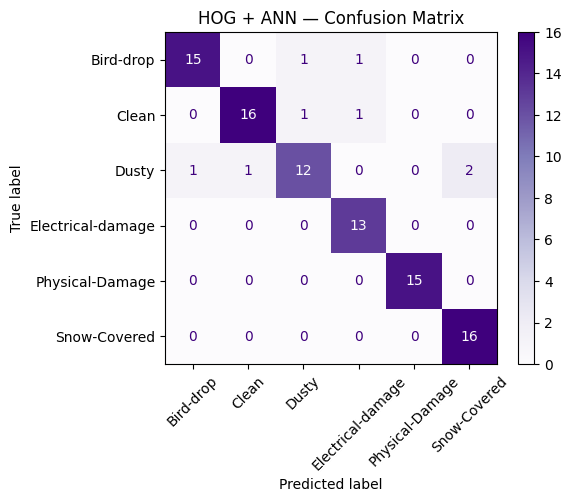


BoVW + SVM — Classification Report
                   precision    recall  f1-score   support

        Bird-drop      0.882     0.882     0.882        17
            Clean      0.938     0.833     0.882        18
            Dusty      0.733     0.688     0.710        16
Electrical-damage      0.812     1.000     0.897        13
  Physical-Damage      1.000     0.867     0.929        15
     Snow-Covered      0.833     0.938     0.882        16

         accuracy                          0.863        95
        macro avg      0.867     0.868     0.864        95
     weighted avg      0.868     0.863     0.863        95



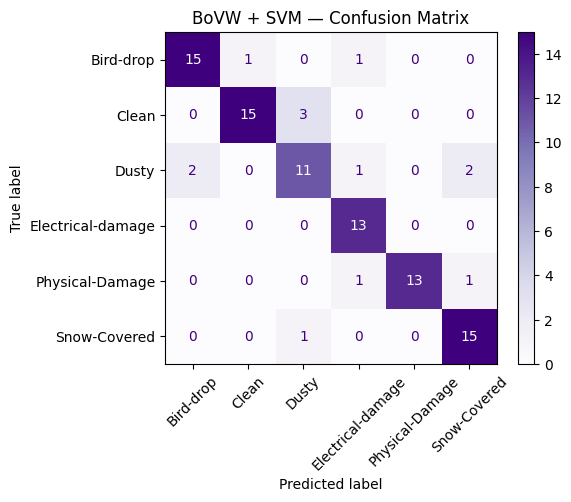


BoVW + KNN — Classification Report
                   precision    recall  f1-score   support

        Bird-drop      1.000     0.941     0.970        17
            Clean      1.000     0.889     0.941        18
            Dusty      0.714     0.625     0.667        16
Electrical-damage      0.923     0.923     0.923        13
  Physical-Damage      0.824     0.933     0.875        15
     Snow-Covered      0.789     0.938     0.857        16

         accuracy                          0.874        95
        macro avg      0.875     0.875     0.872        95
     weighted avg      0.878     0.874     0.873        95



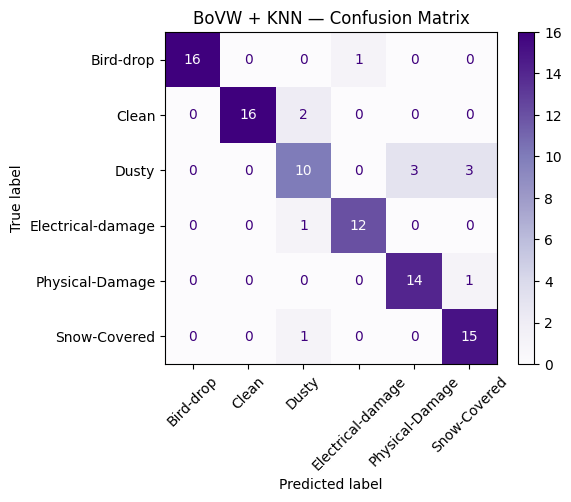


BoVW + ANN — Classification Report
                   precision    recall  f1-score   support

        Bird-drop      0.941     0.941     0.941        17
            Clean      0.947     1.000     0.973        18
            Dusty      1.000     0.750     0.857        16
Electrical-damage      0.929     1.000     0.963        13
  Physical-Damage      1.000     0.933     0.966        15
     Snow-Covered      0.842     1.000     0.914        16

         accuracy                          0.937        95
        macro avg      0.943     0.937     0.936        95
     weighted avg      0.943     0.937     0.935        95



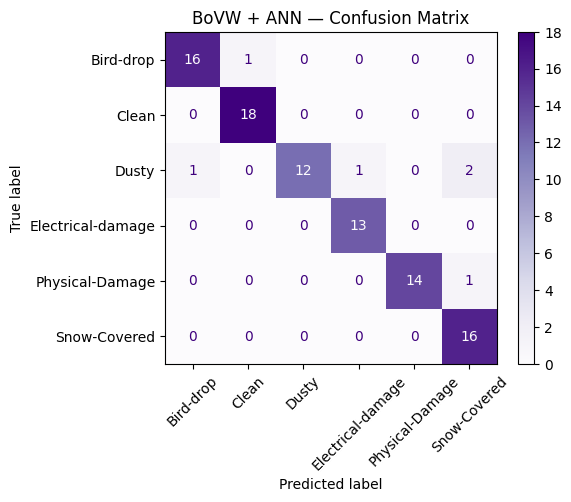


ANN + SIFT (3-Fold CV) — Classification Report
                   precision    recall  f1-score   support

        Bird-drop      1.000     1.000     1.000        17
            Clean      1.000     1.000     1.000        18
            Dusty      1.000     1.000     1.000        16
Electrical-damage      1.000     1.000     1.000        13
  Physical-Damage      1.000     1.000     1.000        15
     Snow-Covered      1.000     1.000     1.000        16

         accuracy                          1.000        95
        macro avg      1.000     1.000     1.000        95
     weighted avg      1.000     1.000     1.000        95



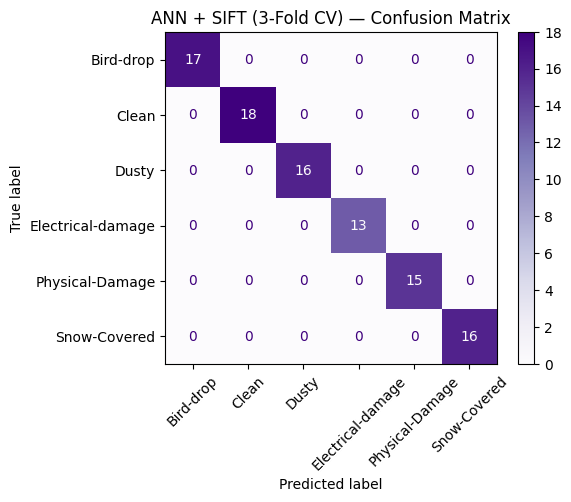


CNN (No Dropout) — Classification Report
                   precision    recall  f1-score   support

        Bird-drop      0.812     0.765     0.788        17
            Clean      0.714     0.833     0.769        18
            Dusty      1.000     0.688     0.815        16
Electrical-damage      0.846     0.846     0.846        13
  Physical-Damage      0.929     0.867     0.897        15
     Snow-Covered      0.650     0.812     0.722        16

         accuracy                          0.800        95
        macro avg      0.825     0.802     0.806        95
     weighted avg      0.821     0.800     0.803        95



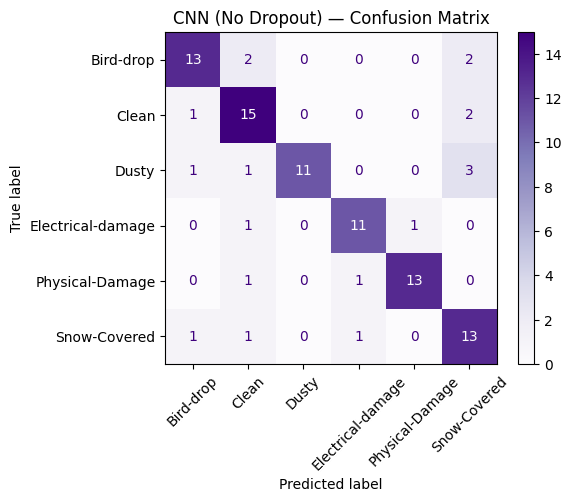


CNN (With Dropout 0.20) — Classification Report
                   precision    recall  f1-score   support

        Bird-drop      0.432     0.941     0.593        17
            Clean      0.700     0.389     0.500        18
            Dusty      0.778     0.438     0.560        16
Electrical-damage      0.875     0.538     0.667        13
  Physical-Damage      0.818     0.600     0.692        15
     Snow-Covered      0.600     0.750     0.667        16

         accuracy                          0.611        95
        macro avg      0.701     0.609     0.613        95
     weighted avg      0.691     0.611     0.608        95



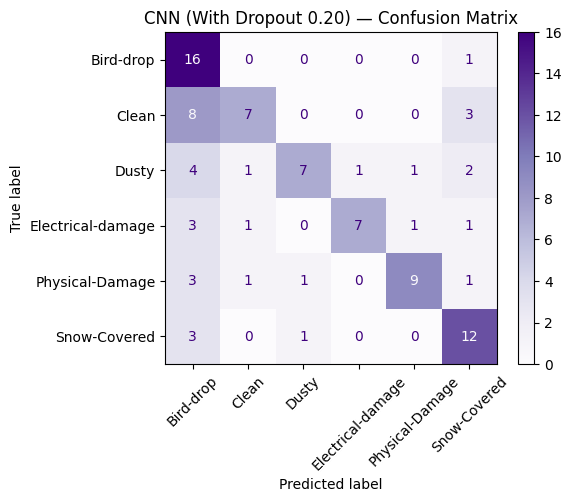


=== Summary (TEST) — Accuracy | Macro P | Macro R | Macro F1 ===
                   name accuracy macro_precision macro_recall macro_f1
 ANN + SIFT (3-Fold CV)    1.000           1.000        1.000    1.000
             BoVW + ANN    0.937           0.943        0.937    0.936
              HOG + ANN    0.916           0.915        0.920    0.916
             BoVW + KNN    0.874           0.875        0.875    0.872
             BoVW + SVM    0.863           0.867        0.868    0.864
              HOG + SVM    0.853           0.858        0.855    0.855
              HOG + KNN    0.832           0.878        0.837    0.840
       CNN (No Dropout)    0.800           0.825        0.802    0.806
CNN (With Dropout 0.20)    0.611           0.701        0.609    0.613


In [ ]:

os.makedirs("results", exist_ok=True)

def cm_and_scores(y_true, y_pred, labels, title, outfile):
    print(f"\n{title} — Classification Report")
    print(classification_report(y_true, y_pred, target_names=labels, digits=3))
    cm = confusion_matrix(y_true, y_pred)


    fig, ax = plt.subplots(figsize=(6,5))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, xticks_rotation=45,cmap = 'Purples', colorbar=True)
    ax.set_title(title + " — Confusion Matrix")
    plt.tight_layout(); plt.savefig(outfile, dpi=150, bbox_inches="tight"); plt.show()
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"name": title, "accuracy": acc, "macro_precision": p, "macro_recall": r, "macro_f1": f1}

def preds_keras_features(model, X):
    return model.predict(X, verbose=0).argmax(axis=1)

def preds_keras_cnn(model, ds):
    y_true, y_pred = [], []
    for xb, yb in ds:
        y_true.append(yb.numpy())
        y_pred.append(model.predict(xb, verbose=0).argmax(axis=1))
    return np.concatenate(y_true), np.concatenate(y_pred)

rows = []

# ---------- HOG (Classical) ----------
rows.append(cm_and_scores(yte, svm_hog.predict(Xte_hog_s), class_names, "HOG + SVM", "results/CM_HOG_SVM.png"))
rows.append(cm_and_scores(yte, knn_hog.predict(Xte_hog_s), class_names, "HOG + KNN", "results/CM_HOG_KNN.png"))
rows.append(cm_and_scores(yte, preds_keras_features(ann_hog, Xte_hog_s), class_names, "HOG + ANN", "results/CM_HOG_ANN.png"))

# ---------- BoVW / SIFT (Classical) ----------
rows.append(cm_and_scores(yte, svm_bow.predict(Xte_bow_s), class_names, "BoVW + SVM", "results/CM_BoVW_SVM.png"))
rows.append(cm_and_scores(yte, knn_bow.predict(Xte_bow_s), class_names, "BoVW + KNN", "results/CM_BoVW_KNN.png"))
rows.append(cm_and_scores(yte, preds_keras_features(ann_bow, Xte_bow_s), class_names, "BoVW + ANN", "results/CM_BoVW_ANN.png"))

# ---------- ANN + SIFT (3-Fold CV) ----------
if 'final_model' in globals():
    rows.append(cm_and_scores(
        yte,
        final_model.predict(Xte_bow_s, verbose=0).argmax(axis=1),
        class_names,
        "ANN + SIFT (3-Fold CV)",
        "results/CM_ANN_SIFT_3FoldCV.png"
    ))

# ---------- CNN ----------
if 'model_no' in globals() and 'y_pred_cnn_no' in globals():
    rows.append(cm_and_scores(
        y_true_cnn, y_pred_cnn_no, class_names,
        "CNN (No Dropout)", "results/CM_CNN_NoDrop.png"
    ))

if 'model_do' in globals() and 'y_pred_cnn_do' in globals():
    rows.append(cm_and_scores(
        y_true_cnn, y_pred_cnn_do, class_names,
        "CNN (With Dropout 0.20)", "results/CM_CNN_Drop.png"
    ))

# ---------- Summary Table ----------
df = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
df.to_csv("results/part3_results.csv", index=False)
print("\n=== Summary (TEST) — Accuracy | Macro P | Macro R | Macro F1 ===")
print(df.to_string(index=False, formatters={
    "accuracy":        lambda v: f"{v:.3f}",
    "macro_precision": lambda v: f"{v:.3f}",
    "macro_recall":    lambda v: f"{v:.3f}",
    "macro_f1":        lambda v: f"{v:.3f}",
}))


